In [0]:
import os
import h5py
import numpy as np

import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten, Activation
from keras.layers.normalization import BatchNormalization
from keras.preprocessing import image

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.figsize'] = (16.0, 4.0) # Set default figure size

In [3]:
from google.colab import drive
drive.mount('/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /gdrive


## Data Handling

In [0]:
# Open the file as readonly
FILEPATH = '/gdrive/My Drive/GreatLearning/Lab/NNDL_Proj_2/SVHN_single_grey1.h5'
h5f = h5py.File(FILEPATH, 'r')

In [5]:
# Load the training, test and validation set
X_train_o = h5f['X_train'][:]
y_train_o = h5f['y_train'][:]
X_test_o = h5f['X_test'][:]
y_test_o = h5f['y_test'][:]
X_val_o = h5f['X_val'][:]
y_val_o = h5f['y_val'][:]

# Close this file
h5f.close()

print('Training set', X_train_o.shape, y_train_o.shape)
print('Validation set', X_val_o.shape, y_val_o.shape)
print('Test set', X_test_o.shape, y_test_o.shape)

Training set (42000, 32, 32) (42000,)
Validation set (60000, 32, 32) (60000,)
Test set (18000, 32, 32) (18000,)


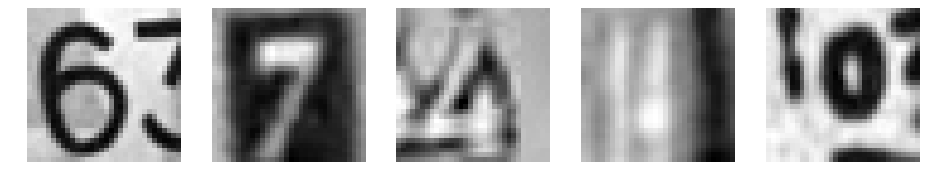

In [6]:
# Display sample list of images 
from matplotlib import pyplot as plt
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(X_train_o[i], cmap='gray')
    plt.plot()
plt.show()

## KNN Image Classification

In [0]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import datasets
from skimage import exposure
import numpy as np
import imutils
import cv2
import sklearn

In [8]:
# Reshape the image data into rows
X_train_k = np.reshape(X_train_o, (X_train_o.shape[0], -1))
X_test_k = np.reshape(X_test_o, (X_test_o.shape[0], -1))
y_train_k = y_train_o
y_test_k = y_test_o

print (X_train_k.shape, X_test_k.shape)
print (y_train_k.shape, y_test_k.shape)

(42000, 1024) (18000, 1024)
(42000,) (18000,)


In [0]:
# Subsample the data to 50%, so that the k-NN model can be executed in less time. Otherwise, it takes too long time. 
num_training = 21000
mask = range(num_training)
X_train_kset = X_train_k[mask]
y_train_kset = y_train_k[mask]

num_test = 9000
mask = range(num_test)
X_test_kset = X_test_k[mask]
y_test_kset = y_test_k[mask]

In [10]:
print (X_train_kset.shape, X_test_kset.shape)
print (y_train_kset.shape, y_test_kset.shape)

(21000, 1024) (9000, 1024)
(21000,) (9000,)


### Implement and apply an optimal k-Nearest Neighbor (kNN) classifier (7.5 points)

In [31]:
# initialize the values of k for our k-Nearest Neighbor classifier along with the
# list of accuracies for each value of k
kVals = range(10, 30, 5)
accuracies = []
 
# loop over various values of `k` for the k-Nearest Neighbor classifier
for k in range(10, 30, 5):
	# train the k-Nearest Neighbor classifier with the current value of `k`
	model = KNeighborsClassifier(n_neighbors=k)
	model.fit(X_train_kset, y_train_kset)
 
	# evaluate the model and update the accuracies list
	score = model.score(X_test_kset, y_test_kset)
	print("k=%d, accuracy=%.2f%%" % (k, score * 100))
	accuracies.append(score)
  
# find the value of k that has the largest accuracy
i = int(np.argmax(accuracies))
print("k=%d achieved highest accuracy of %.2f%% on validation data" % (kVals[i],
	accuracies[i] * 100))

k=10, accuracy=46.73%
k=15, accuracy=47.64%
k=20, accuracy=47.78%
k=25, accuracy=48.17%
k=25 achieved highest accuracy of 48.17% on validation data


### Print the classification metric report (2.5 points)

In [32]:
#Run the model with the best K value 
model = KNeighborsClassifier(n_neighbors=kVals[i])
model.fit(X_train_kset, y_train_kset)
predictions = model.predict(X_test_kset)

print("Classification Report")
print(classification_report(y_test_kset, predictions))

print ("Confusion matrix")
print(confusion_matrix(y_test_kset,predictions))

Classification Report
              precision    recall  f1-score   support

           0       0.41      0.65      0.50       910
           1       0.43      0.68      0.53       894
           2       0.58      0.49      0.53       895
           3       0.40      0.37      0.38       837
           4       0.59      0.60      0.59       892
           5       0.47      0.37      0.41       945
           6       0.44      0.38      0.41       905
           7       0.65      0.57      0.61       870
           8       0.44      0.34      0.38       941
           9       0.52      0.38      0.44       911

    accuracy                           0.48      9000
   macro avg       0.49      0.48      0.48      9000
weighted avg       0.49      0.48      0.48      9000

Confusion matrix
[[589  29  20  27  29  31  51  18  56  60]
 [ 43 611  28  50  49  27  24  34  12  16]
 [ 59 113 436  66  29  29  20  75  30  38]
 [ 64 130  63 311  31  82  32  43  42  39]
 [ 65 135  20  29 532  23  36 

## Neural-Networks Classifier


### Implement and apply a deep neural network classifier including (feedforward neural network, RELU activations) (5 points)

In [0]:
#reshape dataset
X_train = X_train_o.reshape(X_train_o.shape[0],32,32,1)
X_test = X_test_o.reshape(X_test_o.shape[0],32,32,1)
X_val = X_val_o.reshape(X_val_o.shape[0],32,32,1)

In [0]:
#Normalize the data
X_train= X_train.astype('float32')
X_train/=255

X_test= X_test.astype('float32')
X_test/=255

X_val= X_val.astype('float32')
X_val/=255

In [13]:
print(X_train.shape, X_test.shape, X_val.shape) 

(42000, 32, 32, 1) (18000, 32, 32, 1) (60000, 32, 32, 1)


In [0]:
# convert the train and validation to categorical 
y_train = keras.utils.to_categorical(y_train_o, 10)
y_val = keras.utils.to_categorical(y_val_o, 10)

# keep the test for evaluation later
y_test = y_test_o

In [17]:
print(y_train.shape, y_val.shape, y_test.shape) 

(42000, 10) (60000, 10) (18000,)


### Understand and be able to implement (vectorized) backpropagation (cost stochastic gradient descent, cross entropy loss, cost functions) (2.5 points). Implement batch normalization for training the neural network (2.5 points)

In [0]:
# build the keras model
def build_model(optimizer, learning_rate, input_shape=(32, 32, 1)):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=3, input_shape=input_shape, padding="same"))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(32, 3, padding="same"))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(10, activation='softmax'))

    lr = learning_rate
    optimizers = {"SGD": keras.optimizers.SGD(lr=lr), "RMSprop": keras.optimizers.RMSprop(lr=lr),
                  "Adadelta": keras.optimizers.Adadelta(lr=lr), "Adam": keras.optimizers.Adam(lr=lr)}

    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=optimizers[optimizer],
                  metrics=['accuracy'])

    return model

In [19]:
# use the adam optimizer and default learning-rate 
model = build_model(optimizer="Adam", learning_rate=1e-3)
model.summary()








Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 32, 32, 32)        320       
_________________________________________________________________
batch_normalization_1 (Batch (None, 32, 32, 32)        128       
_________________________________________________________________
activation_1 (Activation)    (None, 32, 32, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 32, 32, 32)        9248      
_________________________________________________________________
batch_normalization_2 (Batch (None, 32, 32, 32)        128       
_________________________________________________________________
activation_2 (Activation)    (None, 32, 32, 32)        0       

In [28]:
# model-checkpoint to save weights periodically
save_model = keras.callbacks.ModelCheckpoint("/content/weights.hdf5", monitor='val_acc', mode='max', verbose=0,
                                                 save_best_only=True, save_weights_only=False, period=1)

early_stopping = keras.callbacks.EarlyStopping(monitor='val_acc', min_delta=0, patience=5, verbose=0, mode='max')
 
# train model
model.fit(X_train, y_train,
              batch_size=128,
              epochs=10,
              verbose=1,
              validation_data=(X_val, y_val),
              callbacks=[early_stopping, save_model])

Train on 42000 samples, validate on 60000 samples
Epoch 1/10
42000/42000 [==============================] - 305s 7ms/step - loss: 0.9227 - acc: 0.6975 - val_loss: 1.1842 - val_acc: 0.6195
Epoch 2/10
42000/42000 [==============================] - 307s 7ms/step - loss: 0.7849 - acc: 0.7441 - val_loss: 0.7292 - val_acc: 0.7681
Epoch 3/10
42000/42000 [==============================] - 306s 7ms/step - loss: 0.7222 - acc: 0.7655 - val_loss: 0.9585 - val_acc: 0.7265
Epoch 4/10
42000/42000 [==============================] - 305s 7ms/step - loss: 0.6930 - acc: 0.7731 - val_loss: 0.7657 - val_acc: 0.7684
Epoch 5/10
42000/42000 [==============================] - 306s 7ms/step - loss: 0.6578 - acc: 0.7851 - val_loss: 0.6616 - val_acc: 0.7902
Epoch 6/10
42000/42000 [==============================] - 308s 7ms/step - loss: 0.6218 - acc: 0.7954 - val_loss: 0.6445 - val_acc: 0.7961
Epoch 7/10
42000/42000 [==============================] - 306s 7ms/step - loss: 0.6023 - acc: 0.8024 - val_loss: 0.8688 - 

In [0]:
model.save_weights("/gdrive/My Drive/GreatLearning/Lab/NNDL_Proj_2/NNProj02.h5")

In [30]:
score = model.evaluate(X_val, y_val, verbose=0)
print('Validation Loss: {:.4f}'.format(score[0]))
print('Validation Accuracy: {:.4f}'.format(score[1]))

Validation Loss: 0.6124
Validation Accuracy: 0.8084


In [0]:
# Predict the classification classes for Test-Data
y_test_pred_class = model.predict_classes(X_test)

In [32]:
print("Classification Report")
print(classification_report(y_test, y_test_pred_class))

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.85      0.81      1814
           1       0.83      0.82      0.83      1828
           2       0.90      0.81      0.85      1803
           3       0.77      0.73      0.75      1719
           4       0.81      0.82      0.82      1812
           5       0.79      0.79      0.79      1768
           6       0.71      0.79      0.75      1832
           7       0.86      0.82      0.84      1808
           8       0.78      0.74      0.76      1812
           9       0.77      0.78      0.78      1804

    accuracy                           0.80     18000
   macro avg       0.80      0.80      0.80     18000
weighted avg       0.80      0.80      0.80     18000



In [33]:
print ("Confusion matrix")
print(confusion_matrix(y_test, y_test_pred_class))

Confusion matrix
[[1550   14   20   20   34    7   56   10   11   92]
 [  44 1508   15   31   80    5   43   51   30   21]
 [  31   35 1453   32   45    5    7   93   29   73]
 [  40   36   21 1247   24  174   56   23   60   38]
 [  22   50   24   18 1494   20   81   17   45   41]
 [  18   16   11   87   23 1398  145    7   30   33]
 [  67   18    5   39   55   81 1446   10   95   16]
 [  44   97   47   43   29    7   13 1477   19   32]
 [  51   20    8   73   33   43  151   10 1348   75]
 [ 148   25   17   36   27   27   29   19   63 1413]]


### Understand the differences and trade-offs between traditional and NN classifiers with the help of classification metrics (5 points)



*   Neural Network classification-model outperformed the KNN Classification-model as per the classficiation report for all the classes. This applies to all the various accuracy parameters (recall, f1-score, precision)
*   Once a neural network is trained, the training data is no longer needed to produce new predictions. This is obviously not the case with k-NN.
*   Once a neural network is trained on one task, its parameters can be used as a good initializer for another (similar) task. This is a form of transfer learning that cannot be achieved with k-NN.
*   In Neural Network, we can store the weights periodically and load the model with the trained weights. Model will start from the last trained accuracy. This is not possible with k-NN. 
*   k-NN is very simple and requires tuning only one hyperparameter (the value of k), while neural net training involves many hyperparameters controlling the size and structure of the network and the optimization procedure.
*   There is no training involved in KNN. During testing, k neighbors with minimum distance, will take part in classification /regression. Hence, prediction needs the have training-data as well. Due to this, it takes too long for prediction. 



